# Economics S5040 | Problem Set 5
### Optimal Stopping and the McCall Job Search Model
**Name:** Friedman

Losses in Problem 1 are measured in parking spaces away from the office. Running the cells in order reproduces all numbers and figures.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams.update({"figure.figsize": (7.5, 4.2), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

## Problem 1. The parking problem

**(a)** When I pass an open space I can **stop** (park there and take a loss equal to my distance from the office) or **continue** (drive on and hope for something closer). An occupied space gives no choice, I just continue. It's an optimal-stopping problem because the only decision is *when* to stop, and each choice changes where I am and which spaces are still available to me. Rejecting an open space is irreversible because the street is one-way: once I pass it that option is gone for good, and all I keep is the chance at spaces further ahead.

**(b)** Subtracting $pS$ from $S$ term by term,
$$S-pS=p+p^2+p^3+\cdots=\frac{p}{1-p},$$
which is just a geometric series (converges since $0<p<1$). So $(1-p)S=p/(1-p)$ and $S=\dfrac{p}{(1-p)^2}$.

**(c)** Past the office I take the first open space. The 1st space beyond is open w.p. $p$. The $k$th space is the first open one only if the $k-1$ spaces before it are all taken and it's open, which by independence has probability $q^{k-1}p$. So the probabilities are $p,\,qp,\,q^2p,\dots$ and the expected loss is
$$\sum_{k\ge1}k\,q^{k-1}p=\frac{p}{q}\sum_{k\ge1}k\,q^{k}=\frac{p}{q}\cdot\frac{q}{(1-q)^2}=\frac{p}{p^2}=\frac1p,$$
using (b) with $q$ in place of $p$. Intuitively, the number of spaces I go is geometric with success probability $p$, so on average it takes $1/p$ tries. As $p\to0$ open spaces are rare and the expected walk blows up. As $p\to1$ the very next space is almost surely open and the loss goes to 1, which is the best possible once I've passed the office.

**(d)** At the office, w.p. $p$ the space is open and I park for a loss of 0; w.p. $1-p$ it's taken and I get $1/p$ from (c):
$$V(0)=p\cdot 0+(1-p)\cdot\frac1p=\frac{1-p}{p}.$$

**(e)** At $n$ spaces before the office:
- w.p. $p$ the space is open, and I take the better of parking now (loss $n$) and continuing (expected loss $V(n-1)$ from the next space), so $\min\{n,V(n-1)\}$ (min because these are losses);
- w.p. $1-p$ it's taken, so I have to continue and get $V(n-1)$.

Adding up gives $V(n)=p\min\{n,V(n-1)\}+(1-p)V(n-1)$. There's no discount factor because the only cost is the walking distance from wherever I end up parking, and it counts the same no matter how many spaces I drove past first. Driving one more space takes a few seconds, so there's no meaningful time preference, and the loss is paid once, when I stop.

**(f)** If the space is open I compare the two terms in the min: park if $n\le V(n-1)$ (at equality I'm indifferent, I'll just park), and continue if $n>V(n-1)$.

Why a cutoff: rewriting (e), $V(n)=V(n-1)+p\min\{n-V(n-1),0\}\le V(n-1)$, so $V$ is weakly decreasing in $n$ (starting further back only adds options). So $n-V(n-1)$ is strictly increasing in $n$: stopping gets worse the further away I am, while continuing gets weakly better. The two can cross only once, giving "ignore open spaces until I'm within $n^*$ of the office, then take the first open one."

**(g)** Close to the office I park at any open space, so there $V(m)=pm+qV(m-1)$ with $V(0)=q/p$. Guessing $V(m)=m+a+bq^m$ and matching terms gives $a=-q/p$ and $b=2q/p$, so
$$V(m)=m+\frac{q}{p}\left(2q^m-1\right)\qquad(\text{check: } V(0)=q/p).$$
Now go by induction. I always park at the office ($n=0$, loss 0), and suppose I park at every open space at positions $0,\dots,n-1$. Then I also park at $n$ iff
$$n\le V(n-1)=n-1+\frac qp\left(2q^{n-1}-1\right)\iff p\le 2q^n-q\iff \frac12\le q^n=(1-p)^n,$$
using $p+q=1$. Since $(1-p)^n$ falls with $n$, this holds for $n=0,1,\dots$ up to some point and then fails for good, which is the cutoff from (f). Taking logs (the inequality flips because $\log(1-p)<0$):
$$n\le n^*(p)=\frac{\log(1/2)}{\log(1-p)}.$$
Since $n$ has to be an integer, the rule is: **park at the first open space once $n\le\lfloor n^*(p)\rfloor$**. If $n^*$ happens to be an integer exactly, I'm indifferent at that space.

In [2]:
p_values = np.array([0.10, 0.20, 0.50, 0.80])
real_cutoff = np.log(0.5) / np.log(1 - p_values)
integer_cutoff = np.floor(real_cutoff + 1e-12).astype(int)  # tiny fudge so p=0.5 (exactly 1) doesn't round down to 0

# brute-force check: run the bellman recursion from V(0) and find the
# furthest space where parking (n <= V(n-1)) is optimal
def dp_cutoff(p, N=100):
    V_prev = (1 - p) / p  # V(0)
    cutoff = 0
    for n in range(1, N):
        if n <= V_prev + 1e-12:
            cutoff = n
        V_prev = p * min(n, V_prev) + (1 - p) * V_prev
    return cutoff

for p, x, n in zip(p_values, real_cutoff, integer_cutoff):
    print(f"p={p:.2f}: real cutoff={x:.4f}, integer cutoff={n}, from bellman recursion={dp_cutoff(p)}")

p=0.10: real cutoff=6.5788, integer cutoff=6, from bellman recursion=6
p=0.20: real cutoff=3.1063, integer cutoff=3, from bellman recursion=3
p=0.50: real cutoff=1.0000, integer cutoff=1, from bellman recursion=1
p=0.80: real cutoff=0.4307, integer cutoff=0, from bellman recursion=0


So I start taking open spaces 6 spaces before the office when $p=0.1$, 3 when $p=0.2$, 1 when $p=0.5$ (where I'm exactly indifferent at $n=1$, since $V(0)=1$), and only at the office itself when $p=0.8$ (then the first open space past it if the office space is taken). The recursion gives the same cutoffs. This makes sense: when spaces are scarce I should grab one early, and when they're plentiful I can wait until I'm close because something better is likely to open up.

**(h)** Discounting is about caring less about a payoff because it arrives later. Here a loss of 3 spaces is a loss of 3 whenever it happens. It's still a DP because today's choice changes the state: passing an open space at $n$ moves me to $n-1$ and throws that option away, and the right comparison is against $V(n-1)$, the best I can do from there. Every position is the same problem one step closer to the office, and the recursion is pinned down by $V(0)$, so we don't need $\beta<1$ to make it converge either.

The $1-p$ is a transition probability, the chance the current space is taken. It's one of the two weights in an expectation, and $p+(1-p)=1$, with $V(n-1)$ showing up in both branches. Nothing about the future is being shrunk. A discount factor would scale down the whole future value even if the future were completely certain.

## Problem 2. The McCall job search model

**(a)** Each period the worker sees an offer and either stops by accepting it (parking) or continues by rejecting it, collecting $c$, and drawing again next period (driving past the space). Like the parking space, a rejected offer can't be recalled. Accepting pays $w$ every period forever:
$$A(w)=w+\beta w+\beta^2w+\cdots=\frac{w}{1-\beta}.$$
Rejecting pays $c$ today, and next period there's a new draw $W'$ from which the worker behaves optimally and gets $V(W')$, so $C=c+\beta E[V(W')]$. $C$ doesn't depend on today's $w$ because offers are iid: once today's offer is turned down it's gone, and it tells me nothing about tomorrow's offer, which is a fresh draw from the same distribution.

**(b)** $V(w)$ is the value of holding offer $w$ and acting optimally from then on. There are only two actions, and (a) already gives the full value of each one (today's payoff plus the discounted value of where it leads). So the best the worker can do is the larger of the two:
$$V(w)=\max\{A(w),C\}=\max\left\{\frac{w}{1-\beta},\;c+\beta E[V(W')]\right\}.$$
Since $C$ contains $V$ itself, this is an equation the function $V$ has to solve, not just a formula.
$A(w)$ is stopping: lock in $w$ forever. $C$ is continuing: take $c$ now and keep the option of choosing again tomorrow.

**(c)** $A(w)$ is continuous and strictly increasing in $w$ (slope $1/(1-\beta)>0$) and $C$ is a constant, so they cross at most once. The worker accepts iff $A(w)\ge C$, i.e. iff $w\ge\bar w$, where at the cutoff the worker is indifferent:
$$\frac{\bar w}{1-\beta}=C\;\Rightarrow\;\bar w=(1-\beta)C.$$
So $\bar w$ is the per-period wage that is worth exactly as much as continuing to search. (If $\bar w$ were below the lowest offer everything would be accepted, and if it were above the highest nothing would be. Neither happens here, see Problem 3.)

Compared with parking, both are cutoff rules from comparing a monotone stopping payoff with a continuation value. In parking, the cutoff is on the state that moves over time (distance), and the continuation value $V(n-1)$ changes as I get closer. McCall is stationary, so $C$ is the same every period and the same $\bar w$ applies forever. Parking says stop once you're *close enough*; McCall says stop once the offer is *good enough*.

## Problem 3. Solving McCall numerically

In [3]:
# parameters
beta = 0.95
c = 12.0
w = np.arange(10.0, 60.0 + 0.5, 0.5)  # the +0.5 makes sure 60 is included
prob = np.ones(len(w)) / len(w)       # uniform offers
tol = 1e-10

def solve_vfi(w, prob, c, beta, tol=1e-10, max_iter=10_000):
    accept_value = w / (1 - beta)
    V = np.zeros_like(w)  # initial guess
    for it in range(1, max_iter + 1):
        C = c + beta * prob @ V  # prob @ V is E[V(W')]
        V_new = np.maximum(accept_value, C)
        error = np.max(np.abs(V_new - V))
        V = V_new
        if error < tol:
            return V, c + beta * prob @ V, it  # recompute C from the converged V
    raise RuntimeError("vfi didn't converge")

V, C, iterations = solve_vfi(w, prob, c, beta, tol)
w_bar = (1 - beta) * C
lowest_accepted = w[w / (1 - beta) >= C].min()

print(f"(a) iterations:        {iterations}")
print(f"(b) continuation C:    {C:.6f}")
print(f"(c) reservation wage:  {w_bar:.6f}")
print(f"    lowest accepted w: {lowest_accepted:.1f}")
print(f"    share of offers accepted: {np.mean(w >= w_bar):.4f}")

(a) iterations:        78
(b) continuation C:    933.469055
(c) reservation wage:  46.673453
    lowest accepted w: 47.0
    share of offers accepted: 0.2673


The worker rejects every offer below about 46.67 and accepts anything from 47 up, so only 27 of the 101 grid wages are acceptable. Even though $c=12$, the worker holds out for a wage well above the average offer of 35, because waiting a few periods costs little when $\beta=0.95$ and a good job lasts forever.

### 3(d) Plot

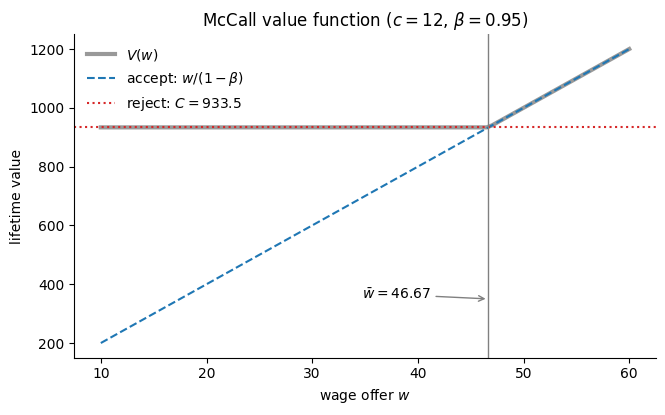

In [4]:
fig, ax = plt.subplots()
ax.plot(w, V, lw=3, alpha=0.4, color="black", label=r"$V(w)$")
ax.plot(w, w / (1 - beta), "--", color="tab:blue", label=r"accept: $w/(1-\beta)$")
ax.axhline(C, ls=":", color="tab:red", label=rf"reject: $C={C:.1f}$")
ax.axvline(w_bar, color="gray", lw=1)
ax.annotate(rf"$\bar w={w_bar:.2f}$", (w_bar, 350), xytext=(w_bar - 12, 350),
            arrowprops=dict(arrowstyle="->", color="gray"))
ax.set(xlabel="wage offer $w$", ylabel="lifetime value",
       title="McCall value function ($c=12$, $\\beta=0.95$)")
ax.legend(frameon=False, loc="upper left")
plt.show()

$V(w)$ is the upper envelope of the flat line $C$ and the rising line $w/(1-\beta)$. Below $\bar w$ the worker rejects, so $V(w)=C$ and today's offer doesn't matter at all (slope 0). Above $\bar w$ the worker accepts, so $V(w)=w/(1-\beta)$ with slope $20$. The kink sits at $\bar w$, where the optimal action switches from continue to stop. It's the same thing as the max in the Bellman equation switching from one branch to the other.

## Problem 4. The value of waiting

These answers were written before running anything. A handy way to sign them: multiply the fixed point for $C$ from Problem 5 by $1-\beta$ and use $\bar w=(1-\beta)C$ to get
$$\bar w-c=\frac{\beta}{1-\beta}\,E\big[(W-\bar w)^+\big].$$
The left side is the cost of waiting one more period (earning $c$ instead of $\bar w$). The right side is the discounted expected gain from getting an offer better than $\bar w$. The left side rises with $\bar w$ and the right side falls, so anything that raises the right side at a given $\bar w$ raises the reservation wage.

**(a)** A higher $c$ directly raises the payoff from rejecting, so $C$ goes up and so does $\bar w=(1-\beta)C$. Unemployment is less painful, so the worker can afford to turn down mediocre offers. In the equation above, $\bar w$ rises by less than $c$ does, because a higher $\bar w$ makes the gain from waiting smaller.

**(b)** A higher $\beta$ raises $\beta/(1-\beta)$, so $\bar w$ rises. A more patient worker puts more weight on the long stream of a better wage relative to the one period of low income it takes to wait for it, so they're more selective.

**(c)** Take "high wages more likely" to mean probability shifts from low to high wages, so the new distribution first-order stochastically dominates the old one. Then for any $C$ the term $E\max\{W/(1-\beta),C\}$ goes up (max is increasing in $W$), so the value of rejecting today's offer $C$ rises. At any given $\bar w$, $E[(W-\bar w)^+]$ also rises, so $\bar w$ goes up. Good future offers make today's so-so offer less attractive.

**(d)** In parking, a higher $p$ makes it more likely that closer spaces will be open, so the expected loss from continuing $V(n-1)$ falls and $n^*(p)=\log(1/2)/\log(1-p)$ falls. I get pickier and wait until I'm closer before parking. In McCall, a better chance of an attractive offer later raises $C$ and $\bar w$, so the worker is also pickier. The common principle is that you stop only when the current option beats the value of keeping your options open. Anything that makes future opportunities better raises the value of continuing and makes the stopping rule more selective.

Quick numerical check afterwards, using the VFI solver from Problem 3:

In [5]:
def res_wage(w, prob, c, beta):
    _, C, _ = solve_vfi(w, prob, c, beta)
    return C, (1 - beta) * C

print("(a) changing c (beta = 0.95)")
for c_test in [8, 12, 16, 20]:
    C_t, wb = res_wage(w, prob, c_test, 0.95)
    print(f"    c={c_test:>2}: C={C_t:8.2f}, w_bar={wb:.3f}")

print("(b) changing beta (c = 12)")
for b_test in [0.90, 0.95, 0.98]:
    C_t, wb = res_wage(w, prob, 12.0, b_test)
    print(f"    beta={b_test:.2f}: w_bar={wb:.3f}")

# tilt the distribution toward high wages: weight grows linearly with w
# (its cdf is below the uniform cdf everywhere, so it's an fosd improvement)
prob_high = (w - 9.5) / (w - 9.5).sum()
print("(c) better offer distribution (c = 12, beta = 0.95)")
for name, q in [("uniform", prob), ("tilted up", prob_high)]:
    C_t, wb = res_wage(w, q, 12.0, 0.95)
    print(f"    {name:>9}: mean offer={q @ w:.2f}, C={C_t:.2f}, w_bar={wb:.3f}")

(a) changing c (beta = 0.95)
    c= 8: C=  920.60, w_bar=46.030
    c=12: C=  933.47, w_bar=46.673
    c=16: C=  946.84, w_bar=47.342
    c=20: C=  960.79, w_bar=48.039
(b) changing beta (c = 12)
    beta=0.90: w_bar=41.924
    beta=0.95: w_bar=46.673
    beta=0.98: w_bar=51.255
(c) better offer distribution (c = 12, beta = 0.95)
      uniform: mean offer=35.00, C=933.47, w_bar=46.673
    tilted up: mean offer=43.33, C=996.68, w_bar=49.834


Everything moves the way I predicted. Going from $c=8$ to $c=20$ raises $\bar w$ by only about 2, much less than the rise of 12 in $c$ itself, which matches the less-than-one-for-one effect in (a).

## Problem 5. Solving McCall with the continuation value

**(a)** The Bellman equation $V(w')=\max\{w'/(1-\beta),C\}$ holds at every possible offer, including tomorrow's. Plugging it into $C=c+\beta E[V(W')]$ gives
$$C=c+\beta E\left[\max\left\{\frac{W'}{1-\beta},C\right\}\right].$$
$C$ shows up on both sides, so it's a fixed point in one number. The right side is a contraction in $C$ with modulus $\beta$ (the max moves by at most as much as $C$ does), so there's a unique solution and iterating on it converges.

**(b)** The code below iterates on $C$ directly, then compares it with VFI.

In [6]:
def solve_C(w, prob, c, beta, tol=1e-10, max_iter=10_000):
    accept_value = w / (1 - beta)
    C = c  # start at c, same as the first C that vfi computes from V = 0
    for it in range(1, max_iter + 1):
        C_new = c + beta * prob @ np.maximum(accept_value, C)
        if abs(C_new - C) < tol:
            return C_new, it
        C = C_new
    raise RuntimeError("didn't converge")

C_scalar, it_scalar = solve_C(w, prob, c, beta)
w_bar_scalar = (1 - beta) * C_scalar
print(f"scalar iteration: {it_scalar} iterations, C={C_scalar:.6f}, w_bar={w_bar_scalar:.6f}")
print(f"vfi:              {iterations} iterations, C={C:.6f}, w_bar={w_bar:.6f}")
print(f"difference in C: {abs(C_scalar - C):.1e}")

# rough timing, average over a bunch of solves
reps = 2000
t0 = time.perf_counter()
for _ in range(reps):
    solve_vfi(w, prob, c, beta)
t_vfi = (time.perf_counter() - t0) / reps
t0 = time.perf_counter()
for _ in range(reps):
    solve_C(w, prob, c, beta)
t_scalar = (time.perf_counter() - t0) / reps
print(f"time per solve: vfi {1e6 * t_vfi:.0f} microseconds, scalar {1e6 * t_scalar:.0f} microseconds")

# why so few iterations with beta=0.95: accepted wages don't depend on C,
# so near the fixed point the error shrinks by beta * P(reject) each step
print(f"beta * P(reject) = {beta * np.mean(w < w_bar):.3f}")

scalar iteration: 77 iterations, C=933.469055, w_bar=46.673453
vfi:              78 iterations, C=933.469055, w_bar=46.673453
difference in C: 5.2e-11


time per solve: vfi 327 microseconds, scalar 146 microseconds
beta * P(reject) = 0.696


**(c)** Both methods give the same $C$ and $\bar w$ up to about $10^{-10}$, which is just the tolerance.

**(d)** The scalar iteration is faster, but mainly per iteration, not in the number of iterations. VFI is secretly iterating on $C$ too. Each new $V$ is completely determined by the current $C$ through $V=\max\{w/(1-\beta),C\}$, so each VFI step is one step of the scalar map. The counts differ by one only because VFI spends its first step moving away from the initial guess $V=0$. The scalar version skips building and comparing a whole 101-vector every step, which is why it runs roughly twice as fast in the timing above. Both take well under a millisecond here, but the gap would grow with a finer grid, and with a continuous distribution the scalar method only needs one integral per step instead of a whole function. Both converge in far fewer steps than $\beta^k$ would suggest because offers above $\bar w$ don't depend on $C$, so the error shrinks at about $\beta\Pr(W<\bar w)\approx0.70$ per step.

We can reduce the problem to one dimension because of two features. Offers are iid, so the value of continuing is the same number whatever today's offer is. And a job is permanent, so the value of stopping, $w/(1-\beta)$, is known in closed form. The only unknown is $C$, and once we have it, $\bar w=(1-\beta)C$ and the whole policy follows.

## Problem 6. Job separation

Timing: an employed worker earns $w$ this period. If the job ends, the worker starts next period unemployed and gets a new offer right away, just like someone who rejected an offer.

**(a)** Next period the worker is still employed at $w$ w.p. $1-\delta$, or is back to unemployed (value $U$) w.p. $\delta$:
$$E(w)=w+\beta\big[(1-\delta)E(w)+\delta U\big]\quad\Rightarrow\quad E(w)=\frac{w+\beta\delta U}{1-\beta(1-\delta)}.$$
With $\delta=0$ this is back to $w/(1-\beta)$.

**(b)** With offer $w$ in hand, the unemployed worker's value is
$$V_u(w)=\max\{E(w),\;c+\beta U\},$$
and before the offer is drawn,
$$U=E[V_u(W)]=\sum_j q_j\max\{E(w_j),\;c+\beta U\}.$$
With $\delta=0$, $c+\beta U$ is exactly the $C$ from before.

**(c)** Yes. Offers are still iid, so the value of rejecting, $c+\beta U$, doesn't depend on today's wage. $E(w)$ is still linear and strictly increasing in $w$ with slope $1/(1-\beta(1-\delta))>0$. So there's a single crossing, and the worker accepts iff $w\ge\bar w$, where $E(\bar w)=c+\beta U$, i.e.
$$\bar w=\big(1-\beta(1-\delta)\big)(c+\beta U)-\beta\delta U.$$
The only change is that $\bar w\neq(1-\beta)C$ anymore, since accepting no longer gives a perpetuity.

**(d)** (Written before the numbers below.) A higher $\delta$ means a job lasts only $1/\delta$ periods on average, so a high wage isn't locked in for long. The value of accepting a good job falls, and the gap between a good and a mediocre job shrinks (the slope $1/(1-\beta(1-\delta))$ falls). (For a barely acceptable job, losing it isn't much of a loss since you just go back to searching, so its value can even tick up slightly. The jobs worth holding out for are the ones that lose value.) Holding out for a great offer is worth less when you won't get to keep it, so the reservation wage should fall. Doing the same algebra as in Problem 4 with $E(\bar w)=c+\beta U$ gives
$$\bar w-c=\frac{\beta(1-\delta)}{1-\beta(1-\delta)}\,E\big[(W-\bar w)^+\big],$$
so separation works like a lower "effective" discount factor $\beta(1-\delta)$ on the job. Just like lowering $\beta$ in 4(b), this lowers $\bar w$.

In [7]:
def solve_separation(w, prob, c, beta, delta, tol=1e-10, max_iter=100_000):
    # iterate on U (a scalar again, since offers are still iid)
    U = 0.0
    for it in range(1, max_iter + 1):
        E = (w + beta * delta * U) / (1 - beta * (1 - delta))
        U_new = prob @ np.maximum(E, c + beta * U)
        if abs(U_new - U) < tol:
            U = U_new
            break
        U = U_new
    else:
        raise RuntimeError("didn't converge")
    E = (w + beta * delta * U) / (1 - beta * (1 - delta))
    w_bar = (1 - beta * (1 - delta)) * (c + beta * U) - beta * delta * U
    return U, E, w_bar

for delta in [0.0, 0.02, 0.05, 0.10, 0.20]:
    U, E, wb = solve_separation(w, prob, c, beta, delta)
    # check against the formula in (d)
    b_eff = beta * (1 - delta)
    rhs = c + b_eff / (1 - b_eff) * prob @ np.maximum(w - wb, 0)
    print(f"delta={delta:.2f}: w_bar={wb:7.3f} (formula {rhs:7.3f}), "
          f"E(60)={E[-1]:7.1f}, lowest accepted={w[E >= c + beta * U].min():.1f}")

delta=0.00: w_bar= 46.673 (formula  46.673), E(60)= 1200.0, lowest accepted=47.0
delta=0.02: w_bar= 44.623 (formula  44.623), E(60)= 1128.6, lowest accepted=45.0
delta=0.05: w_bar= 42.121 (formula  42.121), E(60)= 1057.5, lowest accepted=42.5
delta=0.10: w_bar= 38.817 (formula  38.817), E(60)=  982.0, lowest accepted=39.0
delta=0.20: w_bar= 33.851 (formula  33.851), E(60)=  895.2, lowest accepted=34.0


With $\delta=0$ we get Problem 3's $\bar w\approx46.67$ back. As $\delta$ rises, the value of the best job falls and the reservation wage drops, to about 33.85 at $\delta=0.2$. The formula in (d) matches the solver.

## Final question: what did the parking problem teach us?

The parking problem and McCall have the same structure. At each step you can stop and take what's in front of you, or continue, give up the current option for good, and move to a new state where you'll choose optimally again. Both are solved the same way: compare the payoff from stopping with a continuation value ($V(n-1)$ or $C$), write that as a Bellman equation, and get a cutoff rule where the two cross. The $\beta$ in McCall shows up because a wage stream paid over time has to be valued, not because it is what makes the problem dynamic. The parking problem has no $\beta$ at all, and $1-p$ is just a probability over what happens next, yet it still needs dynamic programming. Passing a space changes my state and removes an option, so the right choice today depends on what I can still get tomorrow. So I agree with the statement: discounting is one ingredient of how future payoffs get valued, but the core of dynamic programming is that today's choice changes tomorrow's opportunities. The continuation value is how we put a number on those opportunities.